Cell 1｜安裝套件、上傳基金淨值檔

In [1]:
# ===== Cell 1｜安裝套件、上傳基金淨值檔 =====
!pip -q install openpyxl tabulate
import numpy as np, pandas as pd, json, itertools, matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from google.colab import files

up = files.upload()            # 選 active_fund_nav.csv.xlsx
FUND_FILE = next(iter(up))
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
print("已上傳：", FUND_FILE)

Saving active_fund_nav.csv.xlsx to active_fund_nav.csv.xlsx
已上傳： active_fund_nav.csv.xlsx


Cell 2｜參數設定與事先寫死的成功標準

In [2]:
# ===== Cell 2｜參數設定與事先寫死的成功標準 =====
# 注意：修改 EXEC_LAG 後，請從 Cell 4 起重跑
SEED = 42
START = "2013-01-04"                                      # 主要起點
SENS_STARTS = ["2005-01-07", "2013-01-04", "2016-07-01"]  # 多起點敏感度檢查

H_WEEKS, DD_THR = 13, -0.15   # 前瞻 13 週內最大跌幅超過 -15% = 危險
EXEC_LAG = 1                  # 訊號出來後多延遲 1 週生效
COST = 0.002                  # 每單位換手成本（假設值）
RF_ANNUAL = 0.01              # 現金年報酬（假設值）
RF_W = RF_ANNUAL / 52

MIN_TRAIN, TEST_LEN = 208, 52
INNER_MIN_TRAIN, INNER_TEST_LEN = 104, 26

GRID_LO = [round(x, 2) for x in np.arange(0.05, 0.55, 0.05)]
GRID_HI = [round(x, 2) for x in np.arange(0.20, 0.95, 0.10)]
OBJECTIVE, LAMBDA = "cagr_minus_dd", 0.5   # 效用 = 年化報酬 - λ|MDD|；或改 "calmar"

PRIMARY = "logit_all"
BOOT_N, PERM_N, BLOCK = 2000, 1000, 13
CRISIS = {   # 這檔基金自己的大跌段
    "Crash 2015":       ("2015-04-24", "2015-08-28"),
    "Oct 2018":         ("2018-09-28", "2018-11-30"),
    "COVID 2020":       ("2020-01-20", "2020-04-30"),
    "Rate hikes 21-22": ("2021-11-19", "2022-10-28"),
    "Tariff 2025":      ("2025-01-22", "2025-04-30"),
    "Summer 2026":      ("2026-06-22", "2026-08-07"),
}
MIN_WINDOWS_COVERED = 3
MIN_BETTER_FRAC = 0.6
PERM_ALPHA = 0.10
# 成功 = Calmar 差 95% CI 下界 > 0 且 危機區間條件成立 且 置換 p < PERM_ALPHA

Cell 3｜載入基金淨值、資料稽核、平靜期掃描

In [3]:
# ===== Cell 3｜載入基金淨值、資料稽核、平靜期掃描 =====
def load_fund(path):
    raw = pd.read_excel(path, header=None)
    for v in raw.iloc[:5, 0].astype(str):
        if "下載日期" in v: print("[基金檔]", v)
    d = pd.to_datetime(raw.iloc[:, 0], format="%Y/%m/%d", errors="coerce")
    v = pd.to_numeric(raw.iloc[:, 1], errors="coerce")
    m = d.notna() & v.notna()
    s = pd.Series(v[m].to_numpy(), index=pd.DatetimeIndex(d[m]), name="FUND").sort_index()
    return s[~s.index.duplicated(keep="last")]

def last_complete_friday(ts):
    ts = ts.normalize()
    return ts - pd.Timedelta(days=(ts.weekday() - 4) if ts.weekday() >= 4 else (ts.weekday() + 3))

fund = load_fund(FUND_FILE)
cut = last_complete_friday(fund.index.max())
price = fund.resample("W-FRI").last().ffill(limit=3).loc[:cut].dropna()

# ---- 稽核 ----
same = fund.diff() == 0
stale = int(same.groupby((~same).cumsum()).sum().max())
gaps = fund.index.to_series().diff().dt.days
audit = pd.DataFrame([dict(first=fund.index.min().date(), last=fund.index.max().date(),
                           n_daily=len(fund), weekly_end=price.index.max().date(),
                           n_weekly=len(price), max_stale_run=stale,
                           max_gap_days=int(gaps.max()))])
audit.to_csv(OUT / "audit.csv", index=False)
print(audit.to_string(index=False))
print("間隔 > 10 天的位置：\n", gaps[gaps > 10].tail(10))
assert fund.index.min() <= pd.Timestamp(START) - pd.Timedelta(weeks=60), "START 之前的歷史不足以計算特徵"

# ---- 平靜期掃描：滾動 26 週年化波動率最低的時段 ----
r_all = price.pct_change()
vol26 = (r_all.rolling(26).std() * np.sqrt(52)).dropna()
ok_end = price.index.max() - pd.Timedelta(weeks=6 * 52)
picked = []
for d, val in vol26[vol26.index <= ok_end].sort_values().items():
    if all(abs((d - x).days) > 180 for x, _ in picked):
        picked.append((d, val))
    if len(picked) >= 8: break
print("\n最平靜的 26 週窗口（window_end 可作為候選起點）：")
print(pd.DataFrame(picked, columns=["window_end", "ann_vol_26w"]).sort_values("window_end").to_string(index=False))
v0 = vol26.loc[:START].iloc[-1]
print(f"\nSTART={START} 前 26 週年化波動率 {v0:.1%}，落在全期 {(vol26 < v0).mean():.0%} 分位")

[基金檔] 下載日期 2026/09/22
     first       last  n_daily weekly_end  n_weekly  max_stale_run  max_gap_days
2000-04-10 2026-09-22     6637 2026-09-18      1380              8            13
間隔 > 10 天的位置：
 0
2012-01-30    12.0
2013-02-18    12.0
2015-02-24    11.0
2016-02-15    12.0
2019-02-11    12.0
2021-02-17    12.0
2022-02-07    12.0
2023-01-30    13.0
2025-02-03    12.0
2026-02-23    12.0
Name: 0, dtype: float64

最平靜的 26 週窗口（window_end 可作為候選起點）：
window_end  ann_vol_26w
2005-07-08     0.104256
2007-05-18     0.104376
2012-11-23     0.107961
2013-05-31     0.115225
2014-02-21     0.102592
2016-08-19     0.119884
2017-07-07     0.103842
2020-01-03     0.118158

START=2013-01-04 前 26 週年化波動率 12.5%，落在全期 9% 分位


Cell 4｜定義特徵、標籤、績效指標與回測函式

In [4]:
# ===== Cell 4｜定義特徵、標籤、績效指標與回測函式 =====
GROUPS = {
    "ret":   ["ret_4w", "ret_13w", "ret_26w", "ret_52w"],
    "trend": ["dd_13w", "dd_52w", "ma_gap_26w", "ma_gap_52w"],
    "vol":   ["vol_13w", "vol_52w", "vol_ratio", "worst_wk_13w"],
}
ALL_FEATURES = [c for g in GROUPS.values() for c in g]

def make_features(p):
    r = p.pct_change(); f = pd.DataFrame(index=p.index)
    for n in (4, 13, 26, 52): f[f"ret_{n}w"] = p.pct_change(n)
    f["dd_13w"] = p / p.rolling(13).max() - 1
    f["dd_52w"] = p / p.rolling(52).max() - 1
    f["ma_gap_26w"] = p / p.rolling(26).mean() - 1
    f["ma_gap_52w"] = p / p.rolling(52).mean() - 1
    f["vol_13w"] = r.rolling(13).std() * np.sqrt(52)
    f["vol_52w"] = r.rolling(52).std() * np.sqrt(52)
    f["vol_ratio"] = f["vol_13w"] / f["vol_52w"]
    f["worst_wk_13w"] = r.rolling(13).min()
    return f[ALL_FEATURES]

def forward_dd(p, H, lag):
    """t 週出訊號，實際進場價 = p[t+lag]，看其後 H 週內的最大跌幅。"""
    a = p.to_numpy(float); n = len(a); dd = np.full(n, np.nan)
    for t in range(n):
        e = t + lag
        if e + H > n - 1: break
        fut = a[e + 1:e + H + 1]
        if np.isnan(a[e]) or np.isnan(fut).any(): continue
        dd[t] = fut.min() / a[e] - 1
    return pd.Series(dd, index=p.index)

def build_dataset(p, start):
    F = make_features(p).dropna().loc[start:]       # 特徵用起點前的歷史暖機
    ret = p.pct_change().reindex(F.index)
    dd = forward_dd(p, H_WEEKS, EXEC_LAG).reindex(F.index)
    y = (dd < DD_THR).astype(float).where(dd.notna())
    print(f"[建模資料] {F.index.min().date()} ~ {F.index.max().date()}，{len(F)} 週，危險標籤比例 {y.mean():.1%}")
    return F, y, ret

def metrics(r, periods=52):
    r = np.asarray(r, float); eq = np.cumprod(1 + r)
    peak = np.maximum.accumulate(np.concatenate([[1.0], eq]))[1:]
    mdd = float((eq / peak - 1).min()); cagr = float(eq[-1] ** (periods / len(r)) - 1)
    ex = r - RF_W; vol = float(r.std(ddof=1) * np.sqrt(periods))
    dn = float(np.sqrt(np.mean(np.minimum(ex, 0) ** 2)) * np.sqrt(periods))
    return dict(CAGR=cagr, MDD=mdd, Vol=vol,
                Sharpe=float(ex.mean() * periods / vol) if vol > 0 else np.nan,
                Sortino=float(ex.mean() * periods / dn) if dn > 0 else np.nan,
                Calmar=cagr / abs(mdd) if mdd < 0 else np.nan)

def to_position(p, lo, hi):
    return np.clip(1 - (np.asarray(p, float) - lo) / (hi - lo), 0, 1)

def simulate(ret, sig, lag=EXEC_LAG):
    """t 週訊號 -> 第 t+1+lag 週的報酬才生效。含換手成本，現金部位計利息。"""
    pos = sig.shift(1 + lag).fillna(1.0); turn = pos.diff().abs().fillna(0.0)
    return pos * ret + (1 - pos) * RF_W - COST * turn, pos, turn

def objective(r):
    m = metrics(r)
    if OBJECTIVE == "calmar": return m["Calmar"] if np.isfinite(m["Calmar"]) else -np.inf
    return m["CAGR"] - LAMBDA * abs(m["MDD"])

Cell 5｜Walk-forward 驗證與統計檢定工具

In [5]:
# ===== Cell 5｜Walk-forward 驗證與統計檢定工具（bootstrap、置換、危機區間） =====
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

def make_model(name):
    if name == "logit":
        return Pipeline([("scale", StandardScaler()),
                         ("select", SelectFromModel(LogisticRegression(penalty="l1", solver="liblinear", C=0.3),
                                                    threshold=-np.inf, max_features=lambda X: min(6, X.shape[1]))),
                         ("clf", LogisticRegression(C=0.5, max_iter=1000))])
    return HistGradientBoostingClassifier(max_depth=3, max_iter=150, learning_rate=0.05,
                                          min_samples_leaf=30, l2_regularization=1.0, random_state=SEED)

def fit_predict(name, Xtr, ytr, Xte):
    m = ytr.notna().to_numpy(); Xtr, ytr = Xtr[m], ytr[m]
    if len(ytr) == 0 or ytr.nunique() < 2:
        return np.full(len(Xte), float(ytr.mean()) if len(ytr) else 0.0)
    return make_model(name).fit(Xtr, ytr).predict_proba(Xte)[:, 1]

def purged_splits(n, min_train, test_len, gap):
    s = min_train
    while s < n:
        yield np.arange(0, s - gap), np.arange(s, min(s + test_len, n)); s += test_len

def inner_oof(name, X, y, gap):
    p = np.full(len(X), np.nan)
    for tr, te in purged_splits(len(X), INNER_MIN_TRAIN, INNER_TEST_LEN, gap):
        p[te] = fit_predict(name, X.iloc[tr], y.iloc[tr], X.iloc[te])
    return p

def n_grid(): return sum(1 for lo in GRID_LO for hi in GRID_HI if hi > lo + 0.05)

def select_thresholds(p, ret):
    best = (-np.inf, GRID_LO[0], GRID_HI[0])
    for lo in GRID_LO:
        for hi in GRID_HI:
            if hi <= lo + 0.05: continue
            u = objective(simulate(ret, pd.Series(to_position(p, lo, hi), index=ret.index))[0].to_numpy())
            if u > best[0]: best = (u, lo, hi)
    return best[1], best[2], best[0]

def walk_forward(name, cols, D, y, ret, gap):
    out = pd.DataFrame(index=D.index, columns=["p", "pos"], dtype=float); params = []
    for tr, te in purged_splits(len(D), MIN_TRAIN, TEST_LEN, gap):
        Xtr, ytr, rtr = D.iloc[tr][cols], y.iloc[tr], ret.iloc[tr]
        p_in = inner_oof(name, Xtr, ytr, gap); ok = ~np.isnan(p_in)
        if ok.sum() < 20: lo, hi, u = 0.2, 0.6, np.nan          # 內層樣本太少 -> 固定預設門檻
        else: lo, hi, u = select_thresholds(p_in[ok], rtr[ok])
        p_te = fit_predict(name, Xtr, ytr, D.iloc[te][cols])
        out.iloc[te, 0] = p_te; out.iloc[te, 1] = to_position(p_te, lo, hi)
        params.append(dict(test_start=D.index[te[0]].date(), test_end=D.index[te[-1]].date(),
                           train_weeks=len(tr), lo=lo, hi=hi, train_utility=u))
    return out, pd.DataFrame(params)

def bootstrap_diff(ra, rb, stat, n=BOOT_N, block=BLOCK, seed=SEED):
    ra, rb = np.asarray(ra), np.asarray(rb); T = len(ra); nb = int(np.ceil(T / block))
    rng = np.random.default_rng(seed); o = []
    for _ in range(n):
        st = rng.integers(0, T - block + 1, nb)
        idx = (st[:, None] + np.arange(block)).ravel()[:T]
        o.append(stat(ra[idx]) - stat(rb[idx]))
    o = np.array(o); o = o[~np.isnan(o)]
    return np.percentile(o, [2.5, 50, 97.5])

def permutation_p(sig, ret, n=PERM_N, block=BLOCK, seed=SEED):
    rng = np.random.default_rng(seed); T = len(sig); nb = int(np.ceil(T / block))
    blocks = [sig.iloc[i * block:(i + 1) * block].to_numpy() for i in range(nb)]
    obs = metrics(simulate(ret, sig)[0])["Calmar"]; cnt = 0
    for _ in range(n):
        s = np.concatenate([blocks[i] for i in rng.permutation(nb)])[:T]
        if metrics(simulate(ret, pd.Series(s, index=ret.index))[0])["Calmar"] >= obs: cnt += 1
    return (cnt + 1) / (n + 1)

def window_table(rs, rb, windows=CRISIS):
    rows = []
    for w, (a, b) in windows.items():
        exp = len(pd.date_range(a, b, freq="W-FRI"))
        idx = rs.index[(rs.index >= a) & (rs.index <= b)]
        cov = len(idx) / exp if exp else 0
        if cov < 0.8:
            rows.append(dict(window=w, coverage=cov, strat_MDD=np.nan, bh_MDD=np.nan,
                             strat_ret=np.nan, bh_ret=np.nan, better=np.nan)); continue
        ms, mb = metrics(rs.loc[idx]), metrics(rb.loc[idx])
        rows.append(dict(window=w, coverage=cov, strat_MDD=ms["MDD"], bh_MDD=mb["MDD"],
                         strat_ret=float((1 + rs.loc[idx]).prod() - 1), bh_ret=float((1 + rb.loc[idx]).prod() - 1),
                         better=bool(ms["MDD"] > mb["MDD"])))
    return pd.DataFrame(rows)

Cell 6｜執行 ML 實驗（三個起點的敏感度檢查）

In [6]:
# ===== Cell 6｜執行 ML 實驗：5 個變體 × 3 個起點，輸出多起點敏感度表 =====
def cols_without(*g):
    drop = {c for x in g for c in GROUPS[x]}
    return [c for c in ALL_FEATURES if c not in drop]

VARIANTS = {
    "logit_all":      ("logit", ALL_FEATURES),
    "gbm_all":        ("gbm",   ALL_FEATURES),
    "logit_no_vol":   ("logit", cols_without("vol")),
    "logit_no_trend": ("logit", cols_without("trend")),
    "logit_no_ret":   ("logit", cols_without("ret")),
}

def run_experiment(start):
    np.random.seed(SEED)
    print(f"\n===== START = {start} =====")
    D, y, ret = build_dataset(price, start); gap = H_WEEKS + EXEC_LAG
    oos, folds = {}, {}
    for name, (model, cols) in VARIANTS.items():
        print("  [實驗]", name); oos[name], folds[name] = walk_forward(model, cols, D, y, ret, gap)
    idx = oos[PRIMARY].index[oos[PRIMARY]["pos"].notna()]; r_o = ret.loc[idx]
    sig = {n: o.loc[idx, "pos"] for n, o in oos.items()}
    sig["BuyHold"] = pd.Series(1.0, index=idx)
    sig["MA40_rule"] = (price > price.rolling(40).mean()).astype(float).reindex(idx)
    sig["VolTarget15"] = np.clip(0.15 / D["vol_13w"], 0, 1).reindex(idx)
    rets, rows = {}, []
    for n, s in sig.items():
        r, pos, turn = simulate(r_o, s); rets[n] = r
        m = metrics(r); m.update(Exposure=float(pos.mean()), TurnoverPerYear=float(turn.mean() * 52))
        rows.append(pd.Series(m, name=n))
    perf = pd.DataFrame(rows)
    rs, rb = rets[PRIMARY], rets["BuyHold"]
    ci_c = bootstrap_diff(rs, rb, lambda r: metrics(r)["Calmar"])
    ci_s = bootstrap_diff(rs, rb, lambda r: metrics(r)["Sharpe"])
    p_perm = permutation_p(sig[PRIMARY], r_o)
    win = window_table(rs, rb)
    n_cov = int(win["better"].notna().sum()); n_better = int((win["better"] == True).sum())
    c1 = ci_c[0] > 0
    c2 = n_cov >= MIN_WINDOWS_COVERED and n_better >= MIN_BETTER_FRAC * n_cov
    c3 = p_perm < PERM_ALPHA
    return dict(start=start, D=D, y=y, ret=ret, idx=idx, perf=perf, rets=rets, folds=folds,
                oos=oos, sig=sig,                      # 診斷 Cell 需要
                ci_c=ci_c, ci_s=ci_s, p_perm=p_perm, win=win, n_cov=n_cov, n_better=n_better,
                c1=c1, c2=c2, c3=c3, passed=bool(c1 and c2 and c3))

results = {s: run_experiment(s) for s in sorted(set(SENS_STARTS + [START]))}

summary = pd.DataFrame([dict(
    start=s, oos_from=r["idx"].min().date(), oos_weeks=len(r["idx"]),
    strat_CAGR=r["perf"].loc[PRIMARY, "CAGR"], strat_MDD=r["perf"].loc[PRIMARY, "MDD"],
    bh_CAGR=r["perf"].loc["BuyHold", "CAGR"], bh_MDD=r["perf"].loc["BuyHold", "MDD"],
    calmar_diff_lo=r["ci_c"][0], calmar_diff_hi=r["ci_c"][2], perm_p=r["p_perm"],
    windows=f'{r["n_better"]}/{r["n_cov"]}', passed=r["passed"]) for s, r in results.items()])
summary.to_csv(OUT / "start_sensitivity.csv", index=False)
print("\n===== 多起點敏感度 ====="); print(summary.round(3).to_string(index=False))


===== START = 2005-01-07 =====
[建模資料] 2005-01-07 ~ 2026-09-18，1133 週，危險標籤比例 9.9%
  [實驗] logit_all
  [實驗] gbm_all
  [實驗] logit_no_vol
  [實驗] logit_no_trend
  [實驗] logit_no_ret

===== START = 2013-01-04 =====
[建模資料] 2013-01-04 ~ 2026-09-18，716 週，危險標籤比例 9.5%
  [實驗] logit_all
  [實驗] gbm_all
  [實驗] logit_no_vol
  [實驗] logit_no_trend
  [實驗] logit_no_ret

===== START = 2016-07-01 =====
[建模資料] 2016-07-01 ~ 2026-09-18，534 週，危險標籤比例 12.5%
  [實驗] logit_all
  [實驗] gbm_all
  [實驗] logit_no_vol
  [實驗] logit_no_trend
  [實驗] logit_no_ret

===== 多起點敏感度 =====
     start   oos_from  oos_weeks  strat_CAGR  strat_MDD  bh_CAGR  bh_MDD  calmar_diff_lo  calmar_diff_hi  perm_p windows  passed
2005-01-07 2009-01-02        925       0.211     -0.417    0.269  -0.418          -0.411           0.042   0.946     2/6   False
2013-01-04 2016-12-30        508       0.205     -0.539    0.350  -0.418          -1.063          -0.024   0.979     3/5   False
2016-07-01 2020-06-26        326       0.242     -0.458    0.390  

Cell 7｜產生主報告、圖與最新一週訊號

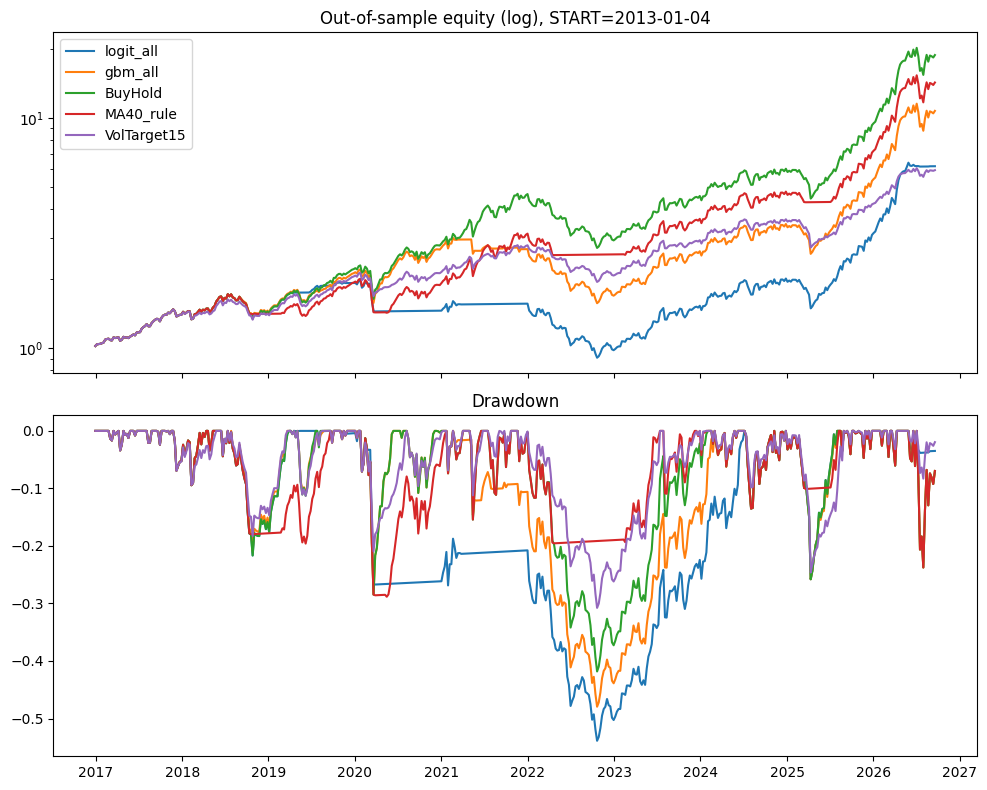

# 自動產生的實驗報告（只用基金淨值）

- 產生時間：2026-10-01 04:19
- 主要起點：2013-01-04；樣外期間：2016-12-30 ~ 2026-09-18（508 週）
- 設定：H=13 週、危險門檻 -15%、執行延遲 1 週、成本 0.20%、現金 1.0%
- 變體 5 個 × 門檻網格 61 × 起點 3 個，總嘗試數約 915（顯著性須打折）

## 樣外績效

|                |   CAGR |    MDD |   Vol |   Sharpe |   Sortino |   Calmar |   Exposure |   TurnoverPerYear |
|:---------------|-------:|-------:|------:|---------:|----------:|---------:|-----------:|------------------:|
| logit_all      |  0.205 | -0.539 | 0.212 |    0.938 |     1.439 |    0.380 |      0.751 |             1.735 |
| gbm_all        |  0.275 | -0.479 | 0.247 |    1.070 |     1.607 |    0.573 |      0.917 |             1.201 |
| logit_no_vol   |  0.279 | -0.418 | 0.214 |    1.214 |     1.890 |    0.667 |      0.804 |             1.845 |
| logit_no_trend |  0.186 | -0.538 | 0.222 |    0.838 |     1.249 |    0.346 |      0.762 |             1.840 |
| logit_no_ret   |  0.179 | -0.572 | 0.228 |    0.792 |     1.198 |    0.313 |      0.753 |             1.315 |
| BuyHold    

In [7]:
# ===== Cell 7｜產生主報告（report.md）、樣外淨值/回撤圖、最新一週訊號 =====
R = results[START]
R["perf"].to_csv(OUT / "performance.csv"); R["folds"][PRIMARY].to_csv(OUT / "primary_folds.csv", index=False)

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for n in [PRIMARY, "gbm_all", "BuyHold", "MA40_rule", "VolTarget15"]:
    eq = (1 + R["rets"][n]).cumprod()
    ax[0].plot(eq.index, eq, label=n); ax[1].plot(eq.index, eq / eq.cummax() - 1, label=n)
ax[0].set_yscale("log"); ax[0].set_title(f"Out-of-sample equity (log), START={START}"); ax[0].legend()
ax[1].set_title("Drawdown"); fig.tight_layout(); fig.savefig(OUT / "equity_drawdown.png", dpi=130); plt.show()

# 最新一週訊號（研究用途）
D, y, ret = R["D"], R["y"], R["ret"]; gap = H_WEEKS + EXEC_LAG
tr = np.arange(0, len(D) - gap); Xtr, ytr, rtr = D.iloc[tr][ALL_FEATURES], y.iloc[tr], ret.iloc[tr]
p_in = inner_oof("logit", Xtr, ytr, gap); ok = ~np.isnan(p_in)
lo, hi, _ = select_thresholds(p_in[ok], rtr[ok])
p_last = fit_predict("logit", Xtr, ytr, D.iloc[[-1]][ALL_FEATURES])[0]
latest = dict(week=str(D.index[-1].date()), danger_prob=float(p_last), lo=lo, hi=hi,
              position=float(to_position(p_last, lo, hi)))

n_trials = len(VARIANTS) * n_grid() * len(results)
md = ["# 自動產生的實驗報告（只用基金淨值）\n",
      f"- 產生時間：{datetime.now():%Y-%m-%d %H:%M}",
      f"- 主要起點：{START}；樣外期間：{R['idx'].min().date()} ~ {R['idx'].max().date()}（{len(R['idx'])} 週）",
      f"- 設定：H={H_WEEKS} 週、危險門檻 {DD_THR:.0%}、執行延遲 {EXEC_LAG} 週、成本 {COST:.2%}、現金 {RF_ANNUAL:.1%}",
      f"- 變體 {len(VARIANTS)} 個 × 門檻網格 {n_grid()} × 起點 {len(results)} 個，總嘗試數約 {n_trials}（顯著性須打折）\n",
      "## 樣外績效\n", R["perf"].to_markdown(floatfmt=".3f"),
      "\n## 統計檢定（主模型 vs 買進持有）\n",
      f"- Calmar 差 95% CI：[{R['ci_c'][0]:.3f}, {R['ci_c'][2]:.3f}]",
      f"- Sharpe 差 95% CI：[{R['ci_s'][0]:.3f}, {R['ci_s'][2]:.3f}]",
      f"- 置換檢定 p 值：{R['p_perm']:.3f}\n",
      "## 危機區間\n", R["win"].to_markdown(index=False, floatfmt=".3f"),
      "\n## 事先指定的成功標準\n",
      f"1. Calmar 差 CI 下界 > 0：{'通過' if R['c1'] else '未通過'}",
      f"2. 可評估區間 {R['n_cov']} 個（需 ≥{MIN_WINDOWS_COVERED}），MDD 優於買進持有 {R['n_better']} 個"
      f"（需 ≥{MIN_BETTER_FRAC:.0%}）：{'通過' if R['c2'] else '未通過'}",
      f"3. 置換 p < {PERM_ALPHA}：{'通過' if R['c3'] else '未通過'}",
      "\n**結論：** " + ("三項標準皆通過。" if R["passed"] else "未同時通過三項標準，沒有足夠證據顯示改善。"),
      "\n## 多起點敏感度\n", summary.to_markdown(index=False, floatfmt=".3f"),
      "\n## 最新一週訊號（研究用途，非投資建議）\n", pd.Series(latest).to_frame("value").to_markdown()]
(OUT / "report.md").write_text("\n".join(md), encoding="utf-8")
print("\n".join(md))

Cell 8｜診斷 ML 為什麼失敗（AUC、回撤區間、極端週部位、換手）

In [8]:
# ===== Cell 8｜診斷 ML 為什麼失敗：AUC、最大回撤區間、極端週部位、換手 =====
from sklearn.metrics import roc_auc_score

for s in results:
    Rr = results[s]; rs, rb = Rr["rets"][PRIMARY], Rr["rets"]["BuyHold"]
    pos = Rr["sig"][PRIMARY].shift(1 + EXEC_LAG).fillna(1.0)      # 實際生效部位
    eq_s, eq_b = (1 + rs).cumprod(), (1 + rb).cumprod()
    dd_s = eq_s / eq_s.cummax() - 1
    tr_ = dd_s.idxmin(); pk = eq_s.loc[:tr_].idxmax()
    p = Rr["oos"][PRIMARY]["p"].dropna(); yy = Rr["y"].reindex(p.index)
    m = yy.notna(); auc = roc_auc_score(yy[m], p[m])
    q = rb.quantile([.05, .95])
    print(f"\n== START {s} ==")
    print(f"策略 MDD {dd_s.min():.1%}：{pk.date()} -> {tr_.date()}；同期買進持有 {eq_b.loc[tr_]/eq_b.loc[pk]-1:.1%}")
    print(f"樣外 AUC {auc:.3f}（0.5 = 無預測力）")
    print(f"平均部位：全期 {pos.mean():.2f}｜最差5%週 {pos[rb<=q[.05]].mean():.2f}｜最好5%週 {pos[rb>=q[.95]].mean():.2f}")
    print(f"每年換手 {Rr['perf'].loc[PRIMARY,'TurnoverPerYear']:.1f}")


== START 2005-01-07 ==
策略 MDD -41.7%：2021-12-31 -> 2022-10-21；同期買進持有 -41.7%
樣外 AUC 0.629（0.5 = 無預測力）
平均部位：全期 0.91｜最差5%週 0.79｜最好5%週 0.73
每年換手 0.5

== START 2013-01-04 ==
策略 MDD -53.9%：2020-01-24 -> 2022-10-21；同期買進持有 19.1%
樣外 AUC 0.429（0.5 = 無預測力）
平均部位：全期 0.75｜最差5%週 0.58｜最好5%週 0.69
每年換手 1.7

== START 2016-07-01 ==
策略 MDD -45.8%：2021-07-16 -> 2022-10-21；同期買進持有 -34.6%
樣外 AUC 0.438（0.5 = 無預測力）
平均部位：全期 0.73｜最差5%週 0.49｜最好5%週 0.74
每年換手 2.0


Cell 9｜均線規則全期檢定（MA26／MA40／MA52，2001–2026）

In [9]:
# ===== Cell 9｜均線規則全期檢定：MA26/40/52 vs 買進持有，含逐年報酬與危機區間 =====
ret_all = price.pct_change().dropna()
idx = ret_all.index[52:]                 # 讓 52 週均線都有值
r_o = ret_all.loc[idx]

def ma_signal(L):
    ma = price.rolling(L).mean()
    return (price > ma).astype(float).where(ma.notna()).reindex(idx)

sigs = {"BuyHold": pd.Series(1.0, index=idx)}
for L in (26, 40, 52):
    sigs[f"MA{L}"] = ma_signal(L)

rets, rows = {}, []
for n, s in sigs.items():
    r, pos, turn = simulate(r_o, s)
    rets[n] = r
    m = metrics(r)
    m.update(Exposure=float(pos.mean()), TurnoverPerYear=float(turn.mean() * 52))
    rows.append(pd.Series(m, name=n))
perf_full = pd.DataFrame(rows)
perf_full.to_csv(OUT / "ma_full_period_performance.csv")
print(f"期間：{idx.min().date()} ~ {idx.max().date()}")
print(perf_full.round(3).to_string())

for L in (26, 40, 52):
    ci = bootstrap_diff(rets[f"MA{L}"], rets["BuyHold"], lambda r: metrics(r)["Calmar"])
    p = permutation_p(sigs[f"MA{L}"], r_o)
    print(f"MA{L}: Calmar 差 95% CI [{ci[0]:.3f}, {ci[2]:.3f}]，置換 p = {p:.3f}")

# 逐年報酬（%）：看改善是否只來自少數幾年
yr = pd.DataFrame({n: (1 + r).resample("YE").prod() - 1 for n, r in rets.items()})
yr.index = yr.index.year; yr.index.name = None
print((yr * 100).round(1).to_string())

# 含 2007-09 的危機區間
WINS = {"GFC 2007-09": ("2007-07-27", "2009-03-06"), **CRISIS}
for L in (26, 40, 52):
    print(f"\nMA{L}")
    print(window_table(rets[f"MA{L}"], rets["BuyHold"], WINS).round(3).to_string(index=False))

期間：2001-04-20 ~ 2026-09-18
          CAGR    MDD    Vol  Sharpe  Sortino  Calmar  Exposure  TurnoverPerYear
BuyHold  0.167 -0.592  0.230   0.745    1.089   0.283     1.000            0.000
MA26     0.173 -0.237  0.184   0.909    1.389   0.730     0.707            3.762
MA40     0.171 -0.288  0.189   0.878    1.321   0.594     0.729            1.959
MA52     0.165 -0.309  0.190   0.847    1.256   0.534     0.732            1.881
MA26: Calmar 差 95% CI [-0.085, 0.665]，置換 p = 0.001
MA40: Calmar 差 95% CI [-0.170, 0.542]，置換 p = 0.002
MA52: Calmar 差 95% CI [-0.182, 0.489]，置換 p = 0.004
      BuyHold  MA26   MA40   MA52
2001     -8.9   0.8    0.8    6.9
2002    -29.2  -2.7  -10.3  -13.3
2003     27.5  22.2   20.8   18.2
2004      3.3   2.3    4.8   -2.3
2005     34.3   8.5   20.7   29.9
2006     12.6   2.2    9.0   12.6
2007     13.2  20.4   17.4    3.9
2008    -48.5  -7.8    1.0    1.0
2009     71.0  53.3   36.4   17.3
2010     14.8   6.1    0.4   13.5
2011    -10.7  -1.0   -2.3   -2.3
2012   

Cell 10｜均線補充檢查（bootstrap 區塊長度、前後半段、2008 年部位）

In [10]:
# ===== Cell 10｜均線補充檢查（事後探索）：bootstrap 區塊長度、前後半段、2008 年部位 =====
# 1) 不同 bootstrap 區塊長度（block=13 為事先設定，block=52 為事後探索）
for L in (26, 40, 52):
    for blk in (13, 52):
        ci = bootstrap_diff(rets[f"MA{L}"], rets["BuyHold"],
                            lambda r: metrics(r)["Calmar"], block=blk)
        print(f"MA{L} block={blk}: [{ci[0]:.3f}, {ci[2]:.3f}]")

# 2) 前後半段是否一致
for nm, (a, b) in {"2001-2016": ("2001-01-01", "2016-12-31"),
                   "2017-2026": ("2017-01-01", "2026-12-31")}.items():
    for n in ("BuyHold", "MA26", "MA40", "MA52"):
        m = metrics(rets[n].loc[a:b])
        print(nm, n, f"CAGR {m['CAGR']:.3f}  MDD {m['MDD']:.3f}  Calmar {m['Calmar']:.2f}")

# 3) 檢查 2008 年有效部位（確認時序合理、無前視）
pos40 = sigs["MA40"].shift(1 + EXEC_LAG)
print(pos40.loc["2007-09":"2009-06"].resample("ME").mean().round(2))

MA26 block=13: [-0.085, 0.665]
MA26 block=52: [0.016, 0.751]
MA40 block=13: [-0.170, 0.542]
MA40 block=52: [-0.095, 0.567]
MA52 block=13: [-0.182, 0.489]
MA52 block=52: [-0.103, 0.440]
2001-2016 BuyHold CAGR 0.068  MDD -0.592  Calmar 0.11
2001-2016 MA26 CAGR 0.088  MDD -0.206  Calmar 0.43
2001-2016 MA40 CAGR 0.093  MDD -0.213  Calmar 0.43
2001-2016 MA52 CAGR 0.082  MDD -0.309  Calmar 0.26
2017-2026 BuyHold CAGR 0.348  MDD -0.418  Calmar 0.83
2017-2026 MA26 CAGR 0.325  MDD -0.237  Calmar 1.37
2017-2026 MA40 CAGR 0.311  MDD -0.288  Calmar 1.08
2017-2026 MA52 CAGR 0.313  MDD -0.286  Calmar 1.10
0
2007-09-30    1.00
2007-10-31    1.00
2007-11-30    1.00
2007-12-31    0.00
2008-01-31    0.00
2008-02-29    0.00
2008-03-31    0.00
2008-04-30    0.00
2008-05-31    0.00
2008-06-30    0.00
2008-07-31    0.00
2008-08-31    0.00
2008-09-30    0.00
2008-10-31    0.00
2008-11-30    0.00
2008-12-31    0.00
2009-01-31    0.00
2009-02-28    0.00
2009-03-31    0.00
2009-04-30    0.25
2009-05-31    1.00


Cell 11｜成本、現金利率、執行延遲的敏感度分析

In [11]:
# ===== Cell 11｜成本、現金利率、執行延遲的敏感度分析（12 組設定） =====
COST0, RF0 = COST, RF_W
rows = []
try:
    for cost, rf, lag in itertools.product([0.002, 0.004], [0.01, 0.02], [0, 1, 2]):
        COST, RF_W = cost, rf / 52
        for n in ("BuyHold", "MA26", "MA40"):
            r, pos, turn = simulate(r_o, sigs[n], lag=lag)
            m = metrics(r)
            rows.append(dict(cost=cost, rf=rf, lag=lag, strat=n,
                             CAGR=m["CAGR"], MDD=m["MDD"], Calmar=m["Calmar"]))
finally:
    COST, RF_W = COST0, RF0            # 還原設定
sens = pd.DataFrame(rows)
sens.to_csv(OUT / "cost_lag_sensitivity.csv", index=False)
print(sens.pivot_table(index=["cost", "rf", "lag"], columns="strat",
                       values=["CAGR", "MDD", "Calmar"]).round(3).to_string())

                  CAGR                Calmar                   MDD              
strat          BuyHold   MA26   MA40 BuyHold   MA26   MA40 BuyHold   MA26   MA40
cost  rf   lag                                                                  
0.002 0.01 0     0.167  0.167  0.180   0.283  0.660  0.747  -0.592 -0.253 -0.241
           1     0.167  0.173  0.171   0.283  0.730  0.594  -0.592 -0.237 -0.288
           2     0.167  0.162  0.169   0.283  0.556  0.593  -0.592 -0.292 -0.284
      0.02 0     0.167  0.171  0.184   0.283  0.684  0.773  -0.592 -0.249 -0.237
           1     0.167  0.177  0.174   0.283  0.745  0.607  -0.592 -0.237 -0.287
           2     0.167  0.166  0.172   0.283  0.574  0.604  -0.592 -0.289 -0.284
0.004 0.01 0     0.167  0.159  0.176   0.283  0.572  0.687  -0.592 -0.277 -0.256
           1     0.167  0.165  0.167   0.283  0.693  0.572  -0.592 -0.237 -0.291
           2     0.167  0.154  0.164   0.283  0.519  0.576  -0.592 -0.296 -0.284
      0.02 0     0.167  0.16

Cell 12｜打包所有輸出並下載

In [12]:
# ===== Cell 12｜打包 outputs 資料夾並下載 =====
!zip -qr outputs.zip outputs
files.download("outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>